In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy
from scipy import sparse
from scipy.sparse import csr_matrix
from functools import reduce
from qutip import *
from matplotlib import cm
import statistics

import numpy as np
import re, ast

from Functions import *
from Hamiltonians import *

# Ladder Dissipative Model

In [20]:
## Defining the system

def H0(e_s,e_l,d_l):
    H_s= tensor(e_s*matrix_element(1,1,2),identity(d_l),identity(2)) # system
    H_l= tensor(identity(2),Qobj(np.sum([e_l*n*matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)) #levels until d_l-2
    H_l+= tensor(identity(2),(e_l*(d_l-1)-e_s)*matrix_element(d_l-2,d_l-2,d_l),identity(2))  #smaller gap at (e_l*(d_l-1)-e_s) energy
    H_l+= tensor(identity(2),e_l*(d_l-1)*matrix_element(d_l-1,d_l-1,d_l),identity(2)) # final gap at e_l*(d_l-1)
    H_b = tensor(identity(2),identity(d_l),e_l*matrix_element(1,1,2))
    return(H_s+H_l+H_b)

def HI(g_sl,g_lb,d_l):
    H_sl= g_sl*tensor(matrix_element(1,0,2),matrix_element(d_l-2,d_l-1,d_l),identity(2)) # system-ladder interaction
    H_lb= g_lb*tensor(identity(2),Qobj(np.sum([matrix_element(n-1,n,d_l).full() for n in range(1,d_l-2)],axis=0)),matrix_element(0,1,2)) # ladder-bath interaction starting from first level below smaller gap, ie d_l-3
    H_lb+=g_lb*tensor(identity(2),matrix_element(d_l-3,d_l-1,d_l),matrix_element(1,0,2)) #   ladder-bath interaction from d_l-1 to d_l-3 jumping the second level which has the wrong gap for this interaction

    return(H_sl+H_lb+H_sl.dag()+H_lb.dag())


Text(0.5, 1.0, 'Dissipative evolution')

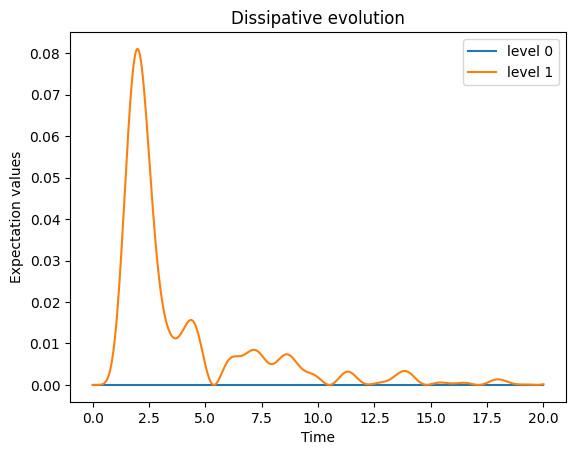

In [3]:
c_l=0.
c_s=0.0
c_b=1
d_l=5
g_sl=1
g_lb=1

H=H0(g_sl,g_lb,d_l)+HI(g_sl,g_lb,d_l)

c_l_plus = tensor(identity(2),c_l * Qobj(np.sum([matrix_element(n+1,n,d_l ).full() for n in range(0,d_l-2)],axis=0)),identity(2))
c_sys_plus = tensor(c_s *matrix_element(1,0,2),identity(d_l),identity(2))
c_bath_minus = tensor(identity(2),identity(d_l),c_b* matrix_element(0,1,2))

e_op_bath_current=c_bath_minus
e_ops_pops_L=[tensor(identity(2),matrix_element(n,n,d_l),identity(2)) for n in range(0,d_l)]
c_ops=[c_l_plus,c_sys_plus,c_bath_minus]
psi0 = tensor(basis(2, 1),basis(d_l,d_l-2),basis(2,0))
times = np.linspace(0.0, 20.0, 1000)
# result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=[tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_minus.dag()*c_bath_minus])
result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=e_ops_pops_L)




fig, ax = plt.subplots()
for n in range(0,d_l-3):
    plt.plot(times,result.expect[n],label="level "+str(n))
# plt.plot(times,result.expect[0])
# plt.plot(times,result.expect[1])
# plt.plot(times,result.expect[2])
# plt.plot(times,result.expect[3])
# plt.plot(result.expect[4])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
# ax.legend(("detection current", "ready state","Ladd lower","|1><1| system","bath current"))
plt.legend()
plt.title("Dissipative evolution")

Text(0.5, 1.0, 'Dissipative evolution')

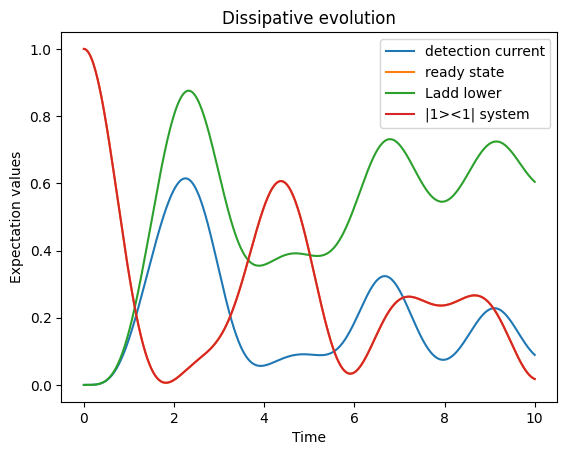

In [189]:


c_l=0.0
c_s=0.0
c_b=0.5
d_l=10

H=H0(1,1,d_l)+HI(1,1,d_l)

c_l_plus = tensor(identity(2),c_l * Qobj(np.sum([matrix_element(n+1,n,d_l ).full() for n in range(0,d_l-2)],axis=0)),identity(2))
c_sys_plus = tensor(c_s *matrix_element(1,0,2),identity(d_l),identity(2))
c_bath_minus = tensor(identity(2),identity(d_l),c_b* matrix_element(0,1,2))

e_op_bath_current=c_bath_minus

c_ops=[c_l_plus,c_sys_plus,c_bath_minus]
psi0 = tensor(basis(2, 1),basis(d_l,d_l-2),basis(2,0))
times = np.linspace(0.0, 10.0, 1000)
result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=[tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_minus.dag()*c_bath_minus])

fig, ax = plt.subplots()
plt.plot(times,result.expect[0])
plt.plot(times,result.expect[1])
plt.plot(times,result.expect[2])
plt.plot(times,result.expect[3])
# plt.plot(result.expect[4])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend(("detection current", "ready state","Ladd lower","|1><1| system","bath current"))
plt.title("Dissipative evolution")

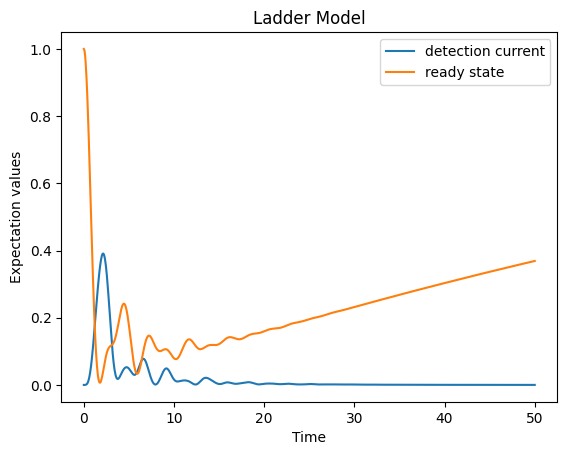

In [4]:



c_l=0.1
c_s=0.0
c_b=1
d_l=10
g_sl=1
g_lb=1

H=H0(g_sl,g_lb,d_l)+HI(g_sl,g_lb,d_l)

c_l_plus = tensor(identity(2),c_l * Qobj(np.sum([matrix_element(n+1,n,d_l ).full() for n in range(0,d_l-2)],axis=0)),identity(2))
c_sys_plus = tensor(c_s *matrix_element(1,0,2),identity(d_l),identity(2))
c_bath_minus = tensor(identity(2),identity(d_l),c_b* matrix_element(0,1,2))

e_op_bath_current=c_bath_minus

c_ops=[c_l_plus,c_sys_plus,c_bath_minus]
psi0 = tensor(basis(2, 1),basis(d_l,d_l-2),basis(2,0))
times = np.linspace(0., 50, 1000)
result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=[tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,d_l-2)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_minus.dag()*c_bath_minus])

fig, ax = plt.subplots()
plt.plot(times,result.expect[0])
plt.plot(times,result.expect[1])
#plt.plot(times[200:300],result.expect[0][200:300])
#plt.plot(times[200:300],result.expect[1][200:300])
# plt.plot(times,result.expect[2])
# plt.plot(times,result.expect[3])
# plt.plot(result.expect[4])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend(("detection current", "ready state","Ladd lower","|1><1| system","bath current"))
plt.title("Ladder Model")
fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/detector.eps', format='eps')

ValueError: row index exceeds matrix dimensions

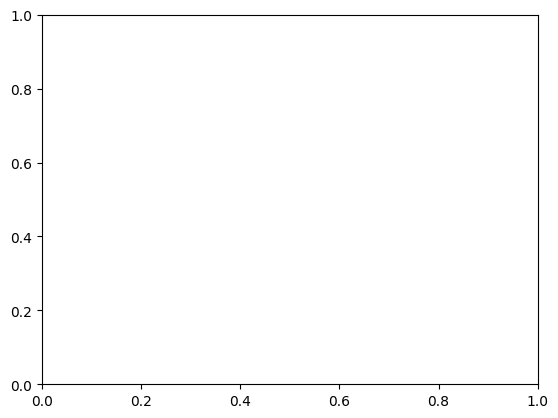

In [8]:

d_l=6
c_l=0.1
c_s=0.0
c_b=1
t_f=100
t_steps=1000


def ME_simulation(c_s,c_l,c_b,g_sl,g_lb,d_l,t_f,t_steps,e_ops):
    H=H0(g_sl,g_lb,d_l)+HI(g_sl,g_lb,d_l)
    c_l_plus = tensor(identity(2),c_l * Qobj(np.sum([matrix_element(n+1,n,d_l ).full() for n in range(0,d_l-2)],axis=0)),identity(2))
    c_sys_plus = tensor(c_s *matrix_element(1,0,2),identity(d_l),identity(2))
    c_bath_minus = tensor(identity(2),identity(d_l),c_b* matrix_element(0,1,2))

    e_o=[tensor(identity(2),identity(d_l),matrix_element(1,1,2)),tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2)),tensor(identity(2),Qobj(np.sum([matrix_element(n,n,d_l).full() for n in range(0,9)],axis=0)),identity(2)),tensor(matrix_element(1,1,2),identity(d_l),identity(2)),c_bath_minus.dag()*c_bath_minus]


    e_op_bath_current=c_bath_minus

    c_o=[c_l_plus,c_sys_plus,c_bath_minus]
    in_state = tensor(basis(2, 1),basis(d_l,d_l-2),basis(2,0))
    times = np.linspace(0.0, t_f, t_steps)
    return(mesolve(H,in_state, tlist=times,c_ops=c_o, e_ops=e_o))

times = np.linspace(0.0, t_f, t_steps)
e_d_current=tensor(identity(2),identity(d_l),matrix_element(1,1,2))
e_readystate=tensor(identity(2),matrix_element(d_l-2,d_l-2,d_l),identity(2))

fig, ax = plt.subplots()

# for n in range(5,7):
#     plt.plot(times,ME_simulation(0.,0.1,1,1,1,n,t_f,t_steps).expect[2])
result= ME_simulation(0.,0.1,1,1,1,d_l,t_f,t_steps,[e_d_current,e_readystate])
plt.plot(times,result.expect[0])
plt.plot(times,result.expect[1])
# plt.plot(times,result.expect[2])
# plt.plot(times,result.expect[3])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend(("detection current", "ready state"))
ax.legend(("Ladd up to 4,d=10","Ladd up to 4,d=20"))

plt.title("Dissipative evolution")

## Finite Temperature implementation

# Minimal purely dissipative model

In [2]:
def H0_min(e_s,e_l):
    H_s= tensor(e_s*matrix_element(1,1,2),identity(3)) # system
    H_l= tensor(identity(2),(e_s+e_l)*matrix_element(2,2,3))  # top ladder
    H_l+= tensor(identity(2),e_l*matrix_element(1,1,3))  # middle
    return(H_s+H_l)

def HI_min(g_sl):
    H_sl= g_sl*tensor(matrix_element(1,0,2),matrix_element(1,2,3)) # system-ladder interaction
    return(H_sl+H_sl.dag())


Text(0.5, 1.0, 'Minimal 3-level Model')

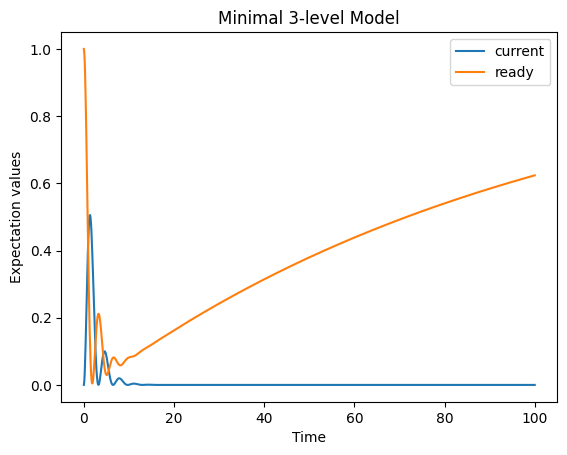

In [3]:
c_l=0.1
c_s=0.0
c_b=1
d_l=10
g_sl=1
g_lb=1

H=H0_min(g_sl,g_lb)+HI_min(g_sl)

c_l_plus = tensor(identity(2),c_l * matrix_element(1,0,3))
c_l_b_minus = tensor(identity(2),c_b * matrix_element(0,2,3))


c_ops=[c_l_plus,c_l_b_minus]

e_ready=tensor(identity(2),matrix_element(1,1,3))
e_current=tensor(tensor(identity(2),c_b * matrix_element(2,2,3)))

e_ops=[e_ready,e_current]

psi0 = tensor(basis(2, 1),basis(3,1))
times = np.linspace(0.0, 100.0, 1000)
result = mesolve(H,psi0, tlist=times,c_ops=c_ops, e_ops=e_ops)

fig, ax = plt.subplots()
plt.plot(times,result.expect[1])
plt.plot(times,result.expect[0])

# plt.plot(result.expect[4])
ax.set_xlabel('Time')
ax.set_ylabel('Expectation values')
ax.legend(( "current","ready"))
plt.title("Minimal 3-level Model")